# EmoExpress: Traditional Machine-Learning Models

## Objective

This notebook trains and evaluates two traditional machine-learning
models for multi-label emotion classification:

1. TF-IDF with Logistic Regression
2. TF-IDF with Linear SVM

Because each GoEmotions example may contain multiple emotions,
One-vs-Rest classification is used.

The models are evaluated using:

- Classification report
- Hamming loss

The classification report provides precision, recall, F1-score, and
support for each emotion, together with micro, macro, weighted, and
sample averages.

Import Library

In [1]:
from pathlib import Path
import ast
import json
import pickle
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier

from sklearn.metrics import hamming_loss, classification_report 

warnings.filterwarnings("ignore")

Configure project paths

In [53]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
METRICS_DIR = OUTPUT_DIR / "metrics"
FIGURE_DIR = OUTPUT_DIR / "figures"

LOGISTIC_MODEL_DIR = MODEL_DIR / "logistic_regression"
SVM_MODEL_DIR = MODEL_DIR / "linear_svm"

for directory in [
    LOGISTIC_MODEL_DIR,
    SVM_MODEL_DIR,
    METRICS_DIR,
    FIGURE_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

# print("Project root:", PROJECT_ROOT)
# print("Processed data:", DATA_DIR)
# print("Models:", MODEL_DIR)

Load the processed datasets

In [3]:
train_path = DATA_DIR / "goemotions_train.csv"
validation_path = DATA_DIR / "goemotions_validation.csv"
test_path = DATA_DIR / "goemotions_test.csv"

train_df = pd.read_csv(train_path)
validation_df = pd.read_csv(validation_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)

Train shape: (43410, 9)
Validation shape: (5426, 7)
Test shape: (5427, 7)


Convert saved list strings back to Python lists

In [4]:
def parse_list_column(value):
    """
    Convert a CSV string representation of a list back into a Python list.
    """
    if isinstance(value, list):
        return value

    if pd.isna(value):
        return []

    try:
        return json.loads(value)
    except json.JSONDecodeError:
        return ast.literal_eval(value)

In [5]:
# apply
LIST_COLUMNS = ["labels","emotion_names","label_vector",
]

for dataframe in [train_df, validation_df, test_df]:
    for column in LIST_COLUMNS:
        dataframe[column] = dataframe[column].apply(parse_list_column)

In [6]:
# test
sample = train_df.iloc[0]

print("Text:", sample["text"])
print("Cleaned text:", sample["clean_text_ml"])
print("Emotion names:", sample["emotion_names"])
print("Label vector:", sample["label_vector"])
print("Vector length:", len(sample["label_vector"]))

Text: My favourite food is anything I didn't have to cook myself.
Cleaned text: my favourite food is anything i didn't have to cook myself.
Emotion names: ['neutral']
Label vector: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
Vector length: 28


Load the emotion label mapping

In [7]:
label_mapping_path = DATA_DIR / "emotion_label_mapping.json"

with open(label_mapping_path, "r", encoding="utf-8") as file:
    label_mapping = json.load(file)

emotion_names = [
    label_mapping[str(index)]
    for index in range(len(label_mapping))
]

NUM_LABELS = len(emotion_names)

print("Number of emotions:", NUM_LABELS)
print(emotion_names)

Number of emotions: 28
['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


Prepare features and labels

In [8]:
X_train_text = train_df["clean_text_ml"].fillna("")
X_validation_text = validation_df["clean_text_ml"].fillna("")
X_test_text = test_df["clean_text_ml"].fillna("")

y_train = np.asarray(
    train_df["label_vector"].tolist(),
    dtype=np.int8,
)

y_validation = np.asarray(
    validation_df["label_vector"].tolist(),
    dtype=np.int8,
)

y_test = np.asarray(
    test_df["label_vector"].tolist(),
    dtype=np.int8,
)

print("Training text shape:", X_train_text.shape)
print("Training labels shape:", y_train.shape)
print("Validation labels shape:", y_validation.shape)
print("Test labels shape:", y_test.shape)

Training text shape: (43410,)
Training labels shape: (43410, 28)
Validation labels shape: (5426, 28)
Test labels shape: (5427, 28)


In [9]:
print("Unique label values:", np.unique(y_train))

Unique label values: [0 1]


**Create the TF-IDF vectorizer**

In [10]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=30_000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    strip_accents="unicode",
)

Fit only on the training data to prevent data leak:

In [11]:
tfidf_start_time = time.perf_counter()

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_validation_tfidf = tfidf_vectorizer.transform(X_validation_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

tfidf_duration = time.perf_counter() - tfidf_start_time

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_validation_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)
print(f"TF-IDF processing time: {tfidf_duration:.2f} seconds")

Training TF-IDF shape: (43410, 30000)
Validation TF-IDF shape: (5426, 30000)
Test TF-IDF shape: (5427, 30000)
TF-IDF processing time: 1.90 seconds


Save the TF-IDF vectorizer

In [52]:
tfidf_path = MODEL_DIR / "tfidf_vectorizer.pkl"

with open(tfidf_path, "wb") as file:
    pickle.dump(tfidf_vectorizer, file)

# print("Saved TF-IDF vectorizer:", tfidf_path)

**Create the evaluation function**
https://scikit-learn.org/stable/modules/model_evaluation.html#hamming-loss

In [13]:
def evaluate_multilabel_model(
    y_true,
    y_pred,
    model_name,
    target_names,
):
    """
    Evaluate a multi-label classification model using
    classification report and Hamming loss.
    """
    print("=" * 100)
    print(model_name)
    print("=" * 100)

    report_text = classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        zero_division=0,
    )

    print(report_text)

    model_hamming_loss = hamming_loss(
        y_true,
        y_pred
    )

    print(
        f"Hamming Loss: "
        f"{model_hamming_loss:.6f}"
    )

    report_dictionary = classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        zero_division=0,
        output_dict=True,
    )

    report_dataframe = pd.DataFrame(
        report_dictionary
    ).transpose()

    return report_dataframe, model_hamming_loss

# Model 1: Logistic Regression

Create the Logistic Regression model
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

In [18]:
logistic_regression_model = OneVsRestClassifier(
    LogisticRegression(
        solver="liblinear",
        max_iter=1_000,
        class_weight="balanced",
        random_state=42,
    ),
    n_jobs=1,
)

Train Logistic Regression

In [20]:
logistic_start_time = time.perf_counter()

logistic_regression_model.fit(X_train_tfidf,y_train,)

logistic_training_time = (time.perf_counter() - logistic_start_time)

print("Logistic Regression training time:", f"{logistic_training_time:.2f} seconds",)

Logistic Regression training time: 13.50 seconds


Generate Logistic Regression predictions

In [21]:
logistic_inference_start = time.perf_counter()

logistic_test_predictions = logistic_regression_model.predict(X_test_tfidf)

logistic_inference_time = (time.perf_counter() - logistic_inference_start)

print("Prediction shape:",logistic_test_predictions.shape)

print(f"Inference time: "f"{logistic_inference_time:.2f} seconds")

Prediction shape: (5427, 28)
Inference time: 0.43 seconds


Evaluate Logistic Regression

In [22]:
logistic_report_df, logistic_hamming_loss = evaluate_multilabel_model( y_true=y_test, y_pred=logistic_test_predictions,
                                                                        model_name="TF-IDF + Logistic Regression", target_names=emotion_names)

TF-IDF + Logistic Regression
                precision    recall  f1-score   support

    admiration       0.52      0.74      0.61       504
     amusement       0.72      0.88      0.79       264
         anger       0.32      0.59      0.41       198
     annoyance       0.22      0.49      0.30       320
      approval       0.20      0.49      0.28       351
        caring       0.17      0.42      0.25       135
     confusion       0.23      0.63      0.33       153
     curiosity       0.30      0.59      0.40       284
        desire       0.32      0.54      0.40        83
disappointment       0.14      0.33      0.20       151
   disapproval       0.21      0.57      0.31       267
       disgust       0.37      0.56      0.45       123
 embarrassment       0.26      0.30      0.28        37
    excitement       0.19      0.50      0.28       103
          fear       0.50      0.71      0.59        78
     gratitude       0.84      0.91      0.88       352
         grief    

In [ ]:
logistic_summary = logistic_report_df.loc[["micro avg","macro avg","weighted avg","samples avg",],[ "precision", "recall", "f1-score", "support",],]

logistic_summary

,precision,recall,f1-score,support
micro avg,0.387400,0.676252,0.492605,6329.0
macro avg,0.355462,0.577480,0.429678,6329.0
weighted avg,0.435248,0.676252,0.522164,6329.0
samples avg,0.453586,0.693815,0.516970,6329.0


For this imbalanced multi-label dataset, focus primarily on:
Micro F1 represents overall prediction performance.
Macro F1 gives equal importance to every emotion.
Hamming loss measures individual label errors.

In [26]:
# Display Logistic Regression emotion performance
logistic_emotion_report = logistic_report_df.loc[emotion_names,["precision","recall","f1-score","support",],].sort_values(by="f1-score", ascending=False,)

# Display the strongest emotions:
print("Highest-performing emotions:")
display(logistic_emotion_report.head(5))

# Display the weakest emotions:
print("Lowest-performing emotions:")
display(logistic_emotion_report.tail(5))

Highest-performing emotions:


,precision,recall,f1-score,support
gratitude,0.840731,0.914773,0.876190,352.0
amusement,0.716923,0.882576,0.791171,264.0
love,0.662252,0.840336,0.740741,238.0
neutral,0.550372,0.785674,0.647303,1787.0
remorse,0.510870,0.839286,0.635135,56.0


Lowest-performing emotions:


,precision,recall,f1-score,support
realization,0.179191,0.427586,0.252546,145.0
caring,0.173252,0.422222,0.245690,135.0
nervousness,0.214286,0.260870,0.235294,23.0
disappointment,0.144928,0.331126,0.201613,151.0
relief,0.085714,0.272727,0.130435,11.0


Save Logistic Regression artifacts

In [51]:
logistic_model_path = (
    LOGISTIC_MODEL_DIR
    / "logistic_regression_model.pkl"
)

with open(logistic_model_path, "wb") as file:
    pickle.dump(
        logistic_regression_model,
        file,
    )

# print("Saved model:", logistic_model_path)

Save the Logistic Regression report

In [50]:
logistic_report_path = (
    METRICS_DIR
    / "logistic_regression_classification_report.csv"
)

logistic_report_df.to_csv(
    logistic_report_path,
    index=True,
)

# print("Saved report:", logistic_report_path)

# Model 2: Linear SVM

Create the Linear SVM model

In [29]:
linear_svm_model = OneVsRestClassifier(
    LinearSVC(
        class_weight="balanced",
        random_state=42,
        max_iter=5_000,
    ),
    n_jobs=-1,
)

Train Linear SVM

In [30]:
svm_start_time = time.perf_counter()

linear_svm_model.fit(
    X_train_tfidf,
    y_train,
)

svm_training_time = (
    time.perf_counter() - svm_start_time
)

print(
    f"Linear SVM training time: "
    f"{svm_training_time:.2f} seconds"
)

Linear SVM training time: 15.58 seconds


Generate Linear SVM predictions

In [32]:
svm_inference_start = time.perf_counter()

svm_test_predictions = linear_svm_model.predict(X_test_tfidf)

svm_inference_time = time.perf_counter() - svm_inference_start

print("Prediction shape:",svm_test_predictions.shape,)

print(f"Inference time: "f"{svm_inference_time:.2f} seconds")

Prediction shape: (5427, 28)
Inference time: 0.03 seconds


Evaluate Linear SVM

In [33]:
svm_report_df, svm_hamming_loss = evaluate_multilabel_model(y_true=y_test,y_pred=svm_test_predictions,model_name="TF-IDF + Linear SVM",target_names=emotion_names,)

TF-IDF + Linear SVM
                precision    recall  f1-score   support

    admiration       0.53      0.63      0.58       504
     amusement       0.69      0.80      0.74       264
         anger       0.36      0.43      0.39       198
     annoyance       0.22      0.32      0.26       320
      approval       0.20      0.31      0.24       351
        caring       0.24      0.29      0.26       135
     confusion       0.27      0.41      0.33       153
     curiosity       0.34      0.45      0.39       284
        desire       0.45      0.33      0.38        83
disappointment       0.21      0.21      0.21       151
   disapproval       0.25      0.35      0.29       267
       disgust       0.43      0.41      0.42       123
 embarrassment       0.25      0.16      0.20        37
    excitement       0.22      0.33      0.27       103
          fear       0.60      0.58      0.59        78
     gratitude       0.89      0.91      0.90       352
         grief       0.50  

In [34]:
# Display the Linear SVM averages
svm_summary = svm_report_df.loc[["micro avg","macro avg","weighted avg","samples avg",],["precision","recall","f1-score","support",],]

svm_summary

,precision,recall,f1-score,support
micro avg,0.449910,0.553484,0.496351,6329.0
macro avg,0.408252,0.431208,0.408217,6329.0
weighted avg,0.462085,0.553484,0.501245,6329.0
samples avg,0.460371,0.571940,0.487912,6329.0


In [35]:
# Display Linear SVM emotion performance
svm_emotion_report = svm_report_df.loc[emotion_names,["precision","recall","f1-score","support",],].sort_values(by="f1-score",ascending=False,)

# Display the strongest emotions:
print("Highest-performing emotions:")
display(svm_emotion_report.head(5))

# Display the weakest emotions:
print("Lowest-performing emotions:")
display(svm_emotion_report.tail(5))

Highest-performing emotions:


,precision,recall,f1-score,support
gratitude,0.886111,0.906250,0.896067,352.0
amusement,0.690554,0.803030,0.742557,264.0
love,0.692593,0.785714,0.736220,238.0
remorse,0.577465,0.732143,0.645669,56.0
neutral,0.547683,0.687745,0.609774,1787.0


Lowest-performing emotions:


,precision,recall,f1-score,support
approval,0.195035,0.313390,0.240437,351.0
disappointment,0.206452,0.211921,0.209150,151.0
embarrassment,0.250000,0.162162,0.196721,37.0
nervousness,0.214286,0.130435,0.162162,23.0
relief,0.090909,0.090909,0.090909,11.0


Save the Linear SVM model

In [37]:
svm_model_path = (
    SVM_MODEL_DIR
    / "linear_svm_model.pkl"
)

with open(svm_model_path, "wb") as file:
    pickle.dump(
        linear_svm_model,
        file,
    )

# print("Saved model:", svm_model_path)

Save the Linear SVM report

In [39]:
svm_report_path = (
    METRICS_DIR
    / "linear_svm_classification_report.csv"
)

svm_report_df.to_csv(
    svm_report_path,
    index=True,
)

# print("Saved report:", svm_report_path)

# Model comparison

Create a simplified comparison table

In [40]:
comparison_df = pd.DataFrame(
    [
        {
            "model": "TF-IDF + Logistic Regression",
            "micro_precision": logistic_report_df.loc[
                "micro avg",
                "precision",
            ],
            "micro_recall": logistic_report_df.loc[
                "micro avg",
                "recall",
            ],
            "micro_f1": logistic_report_df.loc[
                "micro avg",
                "f1-score",
            ],
            "macro_precision": logistic_report_df.loc[
                "macro avg",
                "precision",
            ],
            "macro_recall": logistic_report_df.loc[
                "macro avg",
                "recall",
            ],
            "macro_f1": logistic_report_df.loc[
                "macro avg",
                "f1-score",
            ],
            "weighted_f1": logistic_report_df.loc[
                "weighted avg",
                "f1-score",
            ],
            "samples_f1": logistic_report_df.loc[
                "samples avg",
                "f1-score",
            ],
            "hamming_loss": logistic_hamming_loss,
            "training_time_seconds": logistic_training_time,
            "inference_time_seconds": logistic_inference_time,
        },
        {
            "model": "TF-IDF + Linear SVM",
            "micro_precision": svm_report_df.loc[
                "micro avg",
                "precision",
            ],
            "micro_recall": svm_report_df.loc[
                "micro avg",
                "recall",
            ],
            "micro_f1": svm_report_df.loc[
                "micro avg",
                "f1-score",
            ],
            "macro_precision": svm_report_df.loc[
                "macro avg",
                "precision",
            ],
            "macro_recall": svm_report_df.loc[
                "macro avg",
                "recall",
            ],
            "macro_f1": svm_report_df.loc[
                "macro avg",
                "f1-score",
            ],
            "weighted_f1": svm_report_df.loc[
                "weighted avg",
                "f1-score",
            ],
            "samples_f1": svm_report_df.loc[
                "samples avg",
                "f1-score",
            ],
            "hamming_loss": svm_hamming_loss,
            "training_time_seconds": svm_training_time,
            "inference_time_seconds": svm_inference_time,
        },
    ]
)

comparison_df

,model,micro_precision,micro_recall,micro_f1,macro_precision,macro_recall,macro_f1,weighted_f1,samples_f1,hamming_loss,training_time_seconds,inference_time_seconds
0,TF-IDF + Logistic Regression,0.38740,0.676252,0.492605,0.355462,0.577480,0.429678,0.522164,0.516970,0.058023,13.499936,0.434696
1,TF-IDF + Linear SVM,0.44991,0.553484,0.496351,0.408252,0.431208,0.408217,0.501245,0.487912,0.046783,15.583351,0.027943


Save the comparison table

In [ ]:
comparison_path = (METRICS_DIR/ "traditional_ml_model_comparison.csv")

comparison_df.to_csv(
    comparison_path,
    index=False,
)

# print("Saved comparison:", comparison_path)

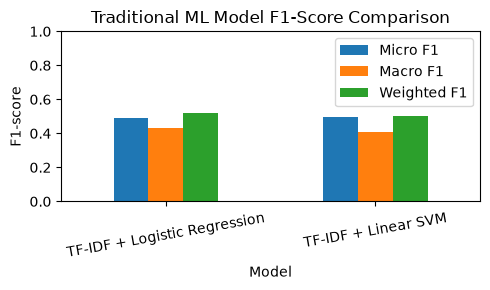

In [ ]:
# Plot the F1-score comparison
f1_comparison_df = comparison_df.set_index(
    "model"
)[
    [
        "micro_f1",
        "macro_f1",
        "weighted_f1",
    ]
]

f1_comparison_df.plot(
    kind="bar",
    figsize=(5, 3),
)

plt.title("Traditional ML Model F1-Score Comparison")
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=10)
plt.legend(
    [
        "Micro F1",
        "Macro F1",
        "Weighted F1",
    ]
)
plt.tight_layout()

f1_figure_path = (FIGURE_DIR/ "traditional_ml_f1_comparison.png")

plt.savefig(
    f1_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# print("Saved figure:", f1_figure_path)

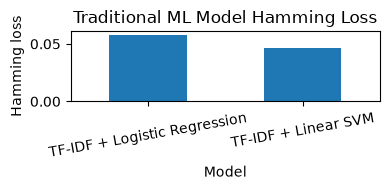

In [ ]:
# Plot Hamming loss
comparison_df.plot(
    x="model",
    y="hamming_loss",
    kind="bar",
    figsize=(4, 2),
    legend=False,
)

plt.title("Traditional ML Model Hamming Loss")
plt.xlabel("Model")
plt.ylabel("Hamming loss")
plt.xticks(rotation=10)
plt.tight_layout()

hamming_figure_path = (FIGURE_DIR/ "traditional_ml_hamming_loss.png")

plt.savefig(
    hamming_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# print("Saved figure:", hamming_figure_path)

In [47]:
# Identify the stronger model
best_model_row = comparison_df.loc[comparison_df["micro_f1"].idxmax()]

print("Best traditional model based on Micro F1:")

display(
    best_model_row.to_frame().T
)

Best traditional model based on Micro F1:


,model,micro_precision,micro_recall,micro_f1,macro_precision,macro_recall,macro_f1,weighted_f1,samples_f1,hamming_loss,training_time_seconds,inference_time_seconds
1,TF-IDF + Linear SVM,0.44991,0.553484,0.496351,0.408252,0.431208,0.408217,0.501245,0.487912,0.046783,15.583351,0.027943


# Conclusion:

Two traditional multi-label emotion classification models were trained using the same TF-IDF text features:

1. One-vs-Rest Logistic Regression
2. One-vs-Rest Linear SVM

The Logistic Regression model achieved:

- Micro precision: 0.387
- Micro recall: 0.676
- Micro F1-score: 0.493
- Macro F1-score: 0.430
- Hamming loss: 0.058

The Linear SVM model achieved:

- Micro precision: 0.450
- Micro recall: 0.553
- Micro F1-score: 0.450
- Macro F1-score: 0.408
- Hamming loss: 0.047

The stronger traditional model was Linear SVM.

Micro F1 was used as the primary comparison metric because it summarizes performance across all label predictions. 
Macro F1 was also considered because it gives equal importance to frequent and rare emotions.

Hamming loss measured the proportion of individual emotion labels that were incorrectly predicted. A lower Hamming loss represents better multi-label performance.

The traditional models provide useful baseline results. However, TF-IDF does not fully capture word order, context, or complex emotional meaning. These results will later be compared with Bi-LSTM, DistilBERT, and RoBERTa models.